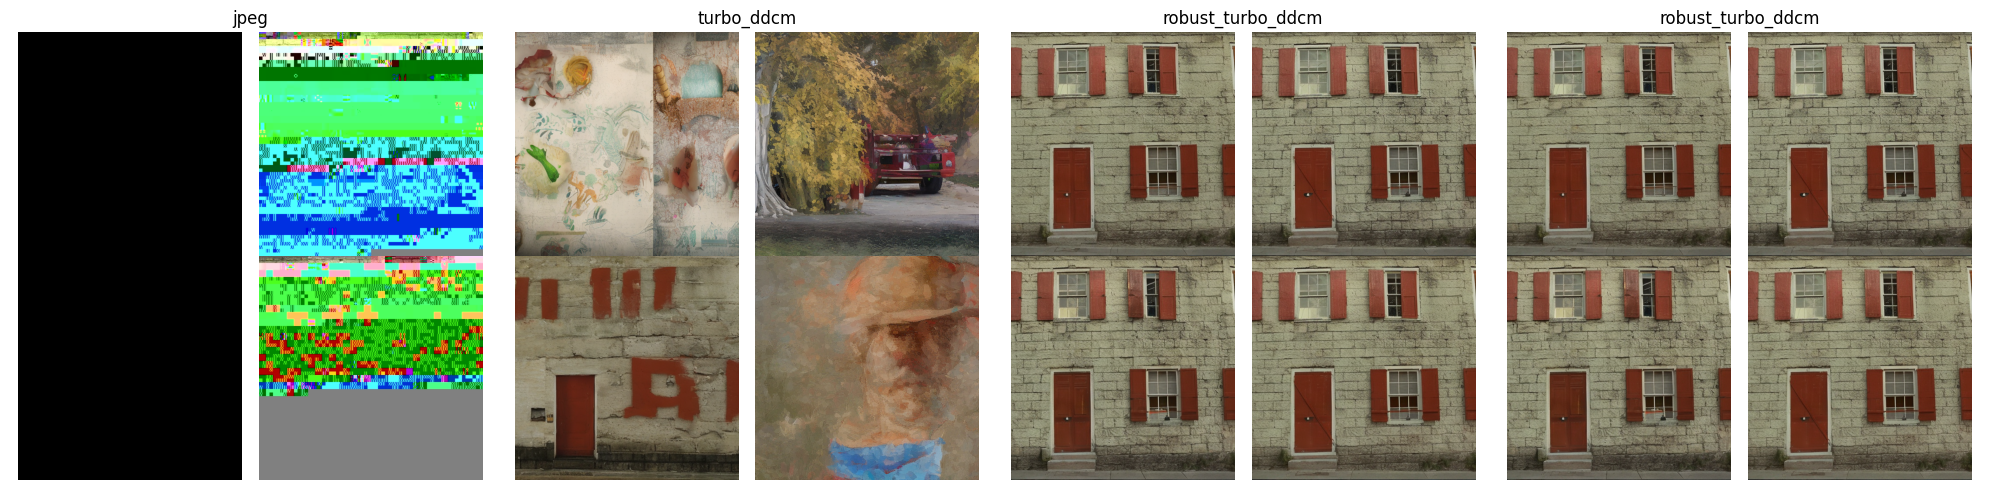

In [32]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def plot_4x(paths, methods):
    assert len(paths) == 4
    for g in paths:
        assert len(g) == 4

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    for col_idx, group in enumerate(paths):
        ax = axes[col_idx]
        ax.axis("off")

        width = 0.5
        height = 0.5

        positions = [
            [0, 0.5],      # top-left
            [0.5, 0.5],     # top-right
            [0, 0],         # bottom-left
            [0.5, 0],        # bottom-right
        ]

        for img_path, pos in zip(group, positions):
            img = Image.open(img_path)
            img = np.array(img)

            x, y = pos
            inset_ax = ax.inset_axes([x, y, width, height])
            inset_ax.imshow(img)
            inset_ax.axis("off")

        ax.set_title(methods[col_idx])

    plt.tight_layout()
    plt.show()


def get_paths(method, img_index, ber_str, num):
    base_path = f'../results/noisy_channel/{method}/samples/ber{ber_str}'

    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Folder does not exist: {base_path}")

    all_files = os.listdir(base_path)
    filtered = [f for f in all_files if f.startswith(str(img_index)) and f.endswith(".png")]
    filtered.sort()
    selected = filtered[:num]
    full_paths = [os.path.join(base_path, f) for f in selected]

    return full_paths

paths = []
methods = ['jpeg', 'turbo_ddcm', 'robust_turbo_ddcm', 'robust_turbo_ddcm']
for method in methods:
    paths += [get_paths(method, 1, '0.001', 4)]

plot_4x(paths, methods)
